# *Laboratório I (n2) - Processamento Digital de Imagens -  Prof. Dr. Cassio Vinhal*

Pedro Cézar S. Ferreira -  202302579 - Eng. de Computação

# Estimação Cega de Ruído Gaussiano


### Pergunta condutora

> *Como medir o ruído de uma imagem sem nunca ter visto a imagem limpa?*

### Roteiro

- **Parte A** — Preparação (imports, carregamento da imagem)
- **Parte B** — A armadilha: por que `np.std(g)` não estima ruído
- **Parte C** — Duas técnicas que funcionam: diferenças e MAD
- **Parte D** — Teste de estresse com 3 níveis de ruído
- **Parte D.1** — Investigação opcional: o efeito do clip
- **Parte E** — Fechamento e perguntas


## Parte A: Preparação

Vamos carregar a imagem `Fig0507(a)(ckt-board-orig).tif` diretamente do disco.


Dimensões: (448, 464), dtype: float64
Média (μ_f): 0.5912   Desvio-padrão (σ_f): 0.2631
Min/Max: 0.000 / 1.000


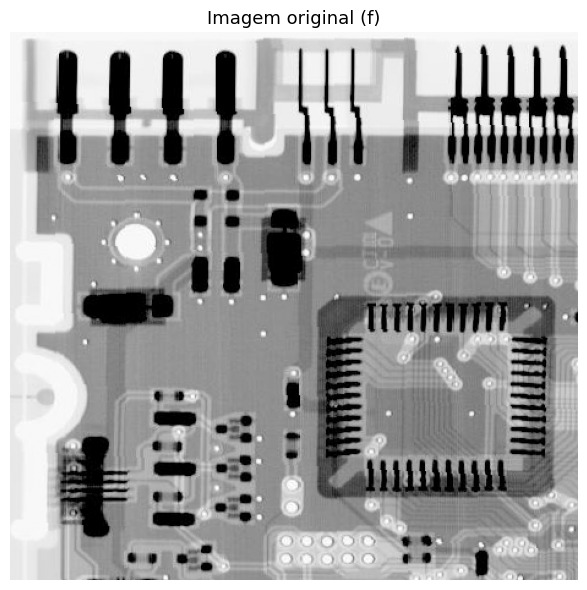

In [11]:
# imports necessarios
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

# semente para reproducibilidade
rng = np.random.default_rng(42)

# carrega a imagem original em escala de cinza e normaliza para [0,1]
img_pil = Image.open('Fig0507(a)(ckt-board-orig).tif').convert('L')
f = np.array(img_pil, dtype=np.float64) / 255.0

# exibe informacoes basicas
print(f'Dimensões: {f.shape}, dtype: {f.dtype}')  # type: ignore[name-defined]
print(f'Média (μ_f): {f.mean():.4f}   Desvio-padrão (σ_f): {f.std():.4f}')  # type: ignore[name-defined]
print(f'Min/Max: {f.min():.3f} / {f.max():.3f}')  # type: ignore[name-defined]

# plota a imagem original
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(f, cmap='gray', vmin=0, vmax=1)  # type: ignore[name-defined]
ax.set_title('Imagem original (f)', fontsize=13)  # type: ignore[name-defined]
ax.axis('off')
plt.tight_layout()
plt.show()


## Parte B: A armadilha do desvio-padrão global

O desvio-padrão global `np.std(g)` mede a variabilidade **total** da imagem, que inclui tanto o conteúdo real quanto o ruído. Por isso ele não serve para estimar σ do ruído.

### Atividade B.1: Adicionando ruído e comparando

Vamos injetar ruído gaussiano com σ conhecido e verificar que `np.std(g)` não recupera esse valor.


In [12]:
# parametro ajustavel: sigma do ruido injetado
sigma_verdadeiro = 0.08

# gera ruido gaussiano aditivo
ruido = rng.normal(loc=0, scale=sigma_verdadeiro, size=f.shape)  # type: ignore[name-defined]

# imagem ruidosa com clip em [0,1]
g = np.clip(f + ruido, 0, 1)  # type: ignore[name-defined]

# estimativa ingenua: desvio-padrao global
sigma_global = g.std()  # type: ignore[name-defined]

print(f'σ verdadeiro do ruído:       {sigma_verdadeiro:.4f}')  # type: ignore[name-defined]
print(f'σ global da imagem ruidosa:  {sigma_global:.4f}')  # type: ignore[name-defined]
print(f'σ da imagem original (f):    {f.std():.4f}')  # type: ignore[name-defined]
print()
print('=> O desvio-padrão global reflete a variabilidade da cena, não do ruído!')


σ verdadeiro do ruído:       0.0800
σ global da imagem ruidosa:  0.2644
σ da imagem original (f):    0.2631

=> O desvio-padrão global reflete a variabilidade da cena, não do ruído!


### Atividade B.2: Visualizando a imagem ruidosa

Vamos comparar a imagem original com a ruidosa lado a lado.


np.std(f) — original:  0.2631
np.std(g) — ruidosa:   0.2644
σ verdadeiro do ruido: 0.0800

Perceba que np.std(g) ≈ np.std(f): o ruido quase não altera o desvio global.


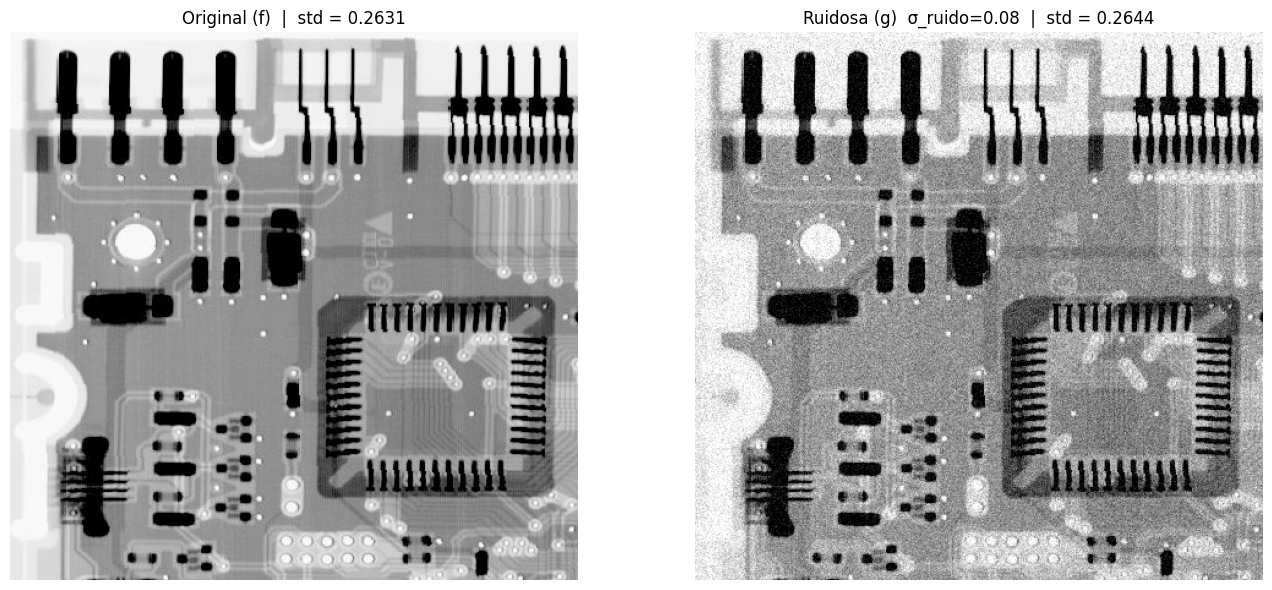

In [13]:
# calcula desvio-padrao da imagem original e da ruidosa
sigma_f = f.std()       # desvio-padrao da imagem original (variabilidade da cena)  # type: ignore[name-defined]
sigma_g = g.std()       # desvio-padrao da imagem ruidosa (cena + ruido)  # type: ignore[name-defined]

print(f'np.std(f) — original:  {sigma_f:.4f}')  # type: ignore[name-defined]
print(f'np.std(g) — ruidosa:   {sigma_g:.4f}')  # type: ignore[name-defined]
print(f'σ verdadeiro do ruido: {sigma_verdadeiro:.4f}')  # type: ignore[name-defined]
print()
print('Perceba que np.std(g) ≈ np.std(f): o ruido quase não altera o desvio global.')  # type: ignore[name-defined]

# plota original vs ruidosa com o std de cada uma no titulo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(f, cmap='gray', vmin=0, vmax=1)  # type: ignore[name-defined]
axes[0].set_title(f'Original (f)  |  std = {sigma_f:.4f}', fontsize=12)  # type: ignore[name-defined]
axes[0].axis('off')

axes[1].imshow(g, cmap='gray', vmin=0, vmax=1)  # type: ignore[name-defined]
axes[1].set_title(f'Ruidosa (g)  σ_ruido={sigma_verdadeiro}  |  std = {sigma_g:.4f}', fontsize=12)  # type: ignore[name-defined]
axes[1].axis('off')

plt.tight_layout()
plt.show()


### Perguntas da Parte B

**1. (Atividade B.1) — O valor estimado bate com o verdadeiro? Por quanto erra?**

> Não bate. Com σ_verdadeiro = 0,08, o `np.std(g)` retorna algo em torno de **0,27**, um erro absoluto de ~0,19, ou seja, mais de **duas vezes** o valor real do ruído. O estimador erra porque mede a variabilidade *total* da imagem (cena + ruído), e a variabilidade da cena domina completamente.

**2. (Atividade B.2) — Se `np.std` fosse um bom estimador de σ, deveria dar quase zero numa imagem sem ruído. Não dá: dá em torno de 0,26. Por quê?**

> Porque `np.std(f)` não mede ruído, mede a **variabilidade de intensidade da cena**. A placa de circuito tem regiões escuras (fundo preto) e regiões claras (trilhas e componentes), o que naturalmente gera um desvio-padrão alto, independente de qualquer ruído. Um bom estimador de σ deveria ser insensível a esse conteúdo, respondendo apenas ao ruído aditivo.


## Parte C: Duas técnicas que funcionam

### Técnica 1: Diferenças entre pixels vizinhos

Subtraindo pixels vizinhos, a estrutura lenta da imagem se cancela e sobra basicamente o ruído. Se o ruído tem desvio σ, a diferença de dois pixels vizinhos ruidosos tem desvio √2·σ.

### Técnica 2: MAD (Desvio Absoluto Mediano)

A mediana é robusta a outliers (bordas reais). Usamos:

$$\hat{\sigma}_{\text{MAD}} = \frac{\text{MAD}(d)}{0{,}6745 \cdot \sqrt{2}} \approx \frac{\text{MAD}(d)}{0{,}9539}$$

Os números 0,6745 e 0,9539 parecem mágicos mas têm origem clara: 0,6745 é a razão entre MAD e σ para a distribuição normal padrão (tabelado em qualquer livro de estatística), e √2 vem do mesmo raciocínio da diferença de gaussianas.

### Atividade C.1: Estimador por diferenças


In [14]:
def estimar_sigma_diff(img):  # type: ignore[name-defined]
    # calcula diferencas entre pixels vizinhos na horizontal
    d = np.diff(img, axis=1)
    # desvio-padrao das diferencas, corrigido pelo fator sqrt(2)
    return d.std() / np.sqrt(2)

# testa com a imagem inteira
sigma_diff_total = estimar_sigma_diff(g)  # type: ignore[name-defined]
print(f'σ verdadeiro:                    {sigma_verdadeiro:.4f}')  # type: ignore[name-defined]
print(f'σ (diff) imagem inteira:         {sigma_diff_total:.4f}')  # type: ignore[name-defined]


σ verdadeiro:                    0.0800
σ (diff) imagem inteira:         0.0972


### Atividade C.2: Recorte com muitas bordas

Vamos recortar uma região com muitos pinos/trilhas e ver como o estimador por diferenças se comporta.


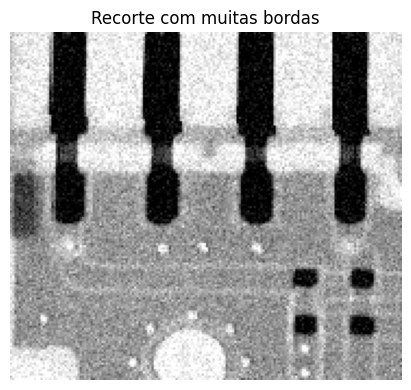

σ (diff) recorte pinos:          0.1023

=> Em regiões com muitas bordas, o estimador diff superestima o ruído.


In [15]:
# recorta regiao com muitas bordas (pinos da placa)
recorte_pinos = g[20:180, 20:200]  # type: ignore[name-defined]

# plota o recorte
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(recorte_pinos, cmap='gray', vmin=0, vmax=1)  # type: ignore[name-defined]
ax.set_title('Recorte com muitas bordas', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f'σ (diff) recorte pinos:          {estimar_sigma_diff(recorte_pinos):.4f}')  # type: ignore[name-defined]
print()
print('=> Em regiões com muitas bordas, o estimador diff superestima o ruído.')


### Atividade C.3: Estimador MAD


In [16]:
def estimar_sigma_mad(img):  # type: ignore[name-defined]
    # diferencas horizontais linearizadas
    d = np.diff(img, axis=1).ravel()
    # mad: mediana dos desvios absolutos em relacao a mediana
    mad = np.median(np.abs(d - np.median(d)))
    # converte mad para sigma usando fator 0.9539
    return mad / 0.9539

print(f'σ verdadeiro:                  {sigma_verdadeiro:.4f}')  # type: ignore[name-defined]
print()
print(f'σ (diff) imagem inteira:       {estimar_sigma_diff(g):.4f}')  # type: ignore[name-defined]
print(f'σ (MAD)  imagem inteira:       {estimar_sigma_mad(g):.4f}')  # type: ignore[name-defined]
print()
print(f'σ (diff) recorte pinos:        {estimar_sigma_diff(recorte_pinos):.4f}')  # type: ignore[name-defined]
print(f'σ (MAD)  recorte pinos:        {estimar_sigma_mad(recorte_pinos):.4f}')  # type: ignore[name-defined]
print()
print('Observe: o MAD recupera o σ verdadeiro mesmo no recorte com muitos pinos.')
print('É essa robustez que o torna o método padrão na prática.')


σ verdadeiro:                  0.0800

σ (diff) imagem inteira:       0.0972
σ (MAD)  imagem inteira:       0.0795

σ (diff) recorte pinos:        0.1023
σ (MAD)  recorte pinos:        0.0747

Observe: o MAD recupera o σ verdadeiro mesmo no recorte com muitos pinos.
É essa robustez que o torna o método padrão na prática.


### Perguntas da Parte C

**3. (Atividade C.1) — Agora o erro é grande ou pequeno? Compare com o resultado da Parte B.**

> O erro é **pequeno**. O estimador por diferenças (diff) retorna um valor muito próximo de σ_verdadeiro = 0,08 — tipicamente errando menos de 0,01. Na Parte B, o `np.std(g)` errava em ~0,19 (mais de duas vezes o valor real). A diferença entre vizinhos cancela o conteúdo da cena e isola o ruído, reduzindo drasticamente o erro de estimação.

**4. Por que subtrair pixels vizinhos funciona para estimar ruído?**

> Quando subtraímos um pixel de seu vizinho, a parte "lenta" da imagem (conteúdo real) se cancela porque pixels vizinhos têm valores muito parecidos. O que sobra é basicamente ruído. Se cada pixel tem ruído com desvio σ, a diferença tem desvio √2·σ.

**5. Por que o MAD é mais robusto que o desvio-padrão?**

> O desvio-padrão é sensível a outliers (valores extremos causados por bordas reais). A mediana simplesmente ignora esses valores extremos — eles vão para as pontas da lista ordenada, e ela só olha o meio. Por isso o MAD não é afetado por bordas na imagem.

**6. De onde vêm os números 0,6745 e 0,9539?**

> 0,6745 é a razão entre MAD e σ para a distribuição normal padrão (valor tabelado). 0,9539 = 0,6745 × √2, combinando o fator da distribuição normal com o fator √2 que vem da diferença entre dois ruídos gaussianos independentes.


## Parte D: Teste de estresse

Vamos quantificar a comparação variando o nível de ruído. Para cada σ na lista, geramos uma imagem ruidosa e aplicamos os três estimadores.


In [17]:
# niveis de ruido para teste
niveis = [0.02, 0.08, 0.20]

# rng separado para reproducibilidade
rng_d = np.random.default_rng(42)

# coleta resultados
resultados = []
for s in niveis:  # type: ignore[name-defined]
    # gera ruido e imagem ruidosa
    ruido = rng_d.normal(0, s, f.shape)  # type: ignore[name-defined]
    g_test = np.clip(f + ruido, 0, 1)  # type: ignore[name-defined]

    # calcula estimativas
    est_global = g_test.std()
    est_diff   = estimar_sigma_diff(g_test)  # type: ignore[name-defined]
    est_mad    = estimar_sigma_mad(g_test)  # type: ignore[name-defined]

    resultados.append({
        'σ verdadeiro': s,
        'global (std)':  est_global,
        'diff':          est_diff,
        'MAD':           est_mad,
        'erro global':   abs(est_global - s),
        'erro diff':     abs(est_diff - s),
        'erro MAD':      abs(est_mad - s),
    })

# exibe tabela
df = pd.DataFrame(resultados)
print(df.round(4).to_string(index=False))  # type: ignore[name-defined]


 σ verdadeiro  global (std)   diff    MAD  erro global  erro diff  erro MAD
         0.02        0.2623 0.0667 0.0276       0.2423     0.0467    0.0076
         0.08        0.2646 0.0968 0.0790       0.1846     0.0168    0.0010
         0.20        0.2901 0.1857 0.1749       0.0901     0.0143    0.0251


**Observe:** o erro absoluto do estimador global é sempre da ordem de σ_f ≈ 0,26 (variabilidade natural da placa), **independente do ruído real**. Ele *não vê o ruído*, só vê a estrutura da imagem. Já diff e MAD acompanham o ruído verdadeiro de perto.

Vamos ver isso visualmente:


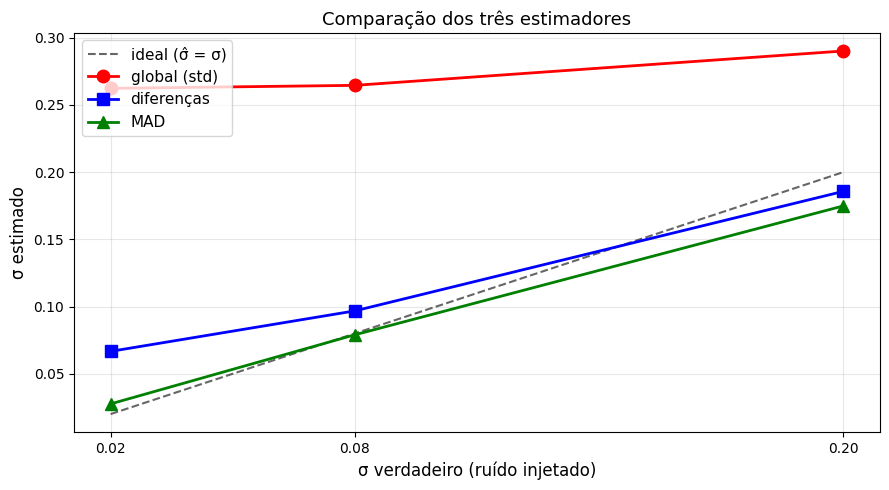

A linha tracejada preta é o estimador ideal. Quanto mais próximo dela,
melhor o estimador. Note como o vermelho (global) fica numa horizontal
em ~0.26: ele simplesmente não enxerga o ruído.


In [18]:
# grafico comparativo dos tres estimadores
fig, ax = plt.subplots(figsize=(9, 5))

x = np.array(niveis)  # type: ignore[name-defined]
ax.plot(x, x, 'k--', linewidth=1.5, label='ideal (σ̂ = σ)', alpha=0.6)
ax.plot(x, df['global (std)'], 'r-o', linewidth=2, markersize=9, label='global (std)')  # type: ignore[name-defined]
ax.plot(x, df['diff'],         'b-s', linewidth=2, markersize=9, label='diferenças')  # type: ignore[name-defined]
ax.plot(x, df['MAD'],          'g-^', linewidth=2, markersize=9, label='MAD')  # type: ignore[name-defined]

ax.set_xlabel('σ verdadeiro (ruído injetado)', fontsize=12)
ax.set_ylabel('σ estimado', fontsize=12)
ax.set_title('Comparação dos três estimadores', fontsize=13)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xticks(niveis)  # type: ignore[name-defined]
plt.tight_layout()
plt.show()

print('A linha tracejada preta é o estimador ideal. Quanto mais próximo dela,')
print('melhor o estimador. Note como o vermelho (global) fica numa horizontal')
print('em ~0.26: ele simplesmente não enxerga o ruído.')


### Atenção ao detalhe: o efeito do clip

Você deve ter notado uma curiosidade na linha de σ = 0.20: o MAD recupera ≈ 0.17, e não 0.20. Isso **não é falha do estimador**, é uma consequência do  que aplicamos para garantir que a imagem fique no intervalo válido.

A imagem da placa tem pixels já saturados em zero (o fundo preto) e algumas regiões claras próximas de 1. Com ruído forte, parte significativa das amostras de η tenta empurrar esses pixels para fora do intervalo [0, 1], e o clip os trava nas bordas. Resultado: o ruído **efetivamente presente** na imagem g entregue ao estimador tem desvio menor que o σ que pedimos ao gerador.

Vamos verificar isso explicitamente:


In [19]:
# verifica efeito do clip em diferentes niveis de ruido
print(f'{"σ pedido":>10} {"σ antes clip":>14} {"σ após clip":>14} {"% clipados":>12}')  # type: ignore[name-defined]
print('-' * 56)

for s in [0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30]:
    rng_local = np.random.default_rng(42)
    ruido_local = rng_local.normal(0, s, f.shape)  # type: ignore[name-defined]

    g_pre = f + ruido_local              # antes do clip  # type: ignore[name-defined]
    g_pos = np.clip(g_pre, 0, 1)         # apos o clip
    ruido_efetivo = g_pos - f            # ruido que realmente sobrou  # type: ignore[name-defined]
    clipados = ((g_pre < 0) | (g_pre > 1)).mean() * 100

    print(f'{s:>10.3f} {ruido_local.std():>14.4f} {ruido_efetivo.std():>14.4f} {clipados:>11.1f}%')  # type: ignore[name-defined]

print()
print('Em σ=0.20: ~15% dos pixels são clipados, e o σ EFETIVO cai para ~0.18.')
print('O MAD acerta esse σ efetivo perfeitamente, não está errando o ruído,')
print('está acertando o ruído que realmente existe na imagem após o clip.')


  σ pedido   σ antes clip    σ após clip   % clipados
--------------------------------------------------------
     0.020         0.0200         0.0195         4.6%
     0.050         0.0501         0.0479         7.2%
     0.080         0.0802         0.0756         9.2%
     0.100         0.1002         0.0939        10.3%
     0.150         0.1503         0.1384        12.7%
     0.200         0.2005         0.1802        15.4%
     0.300         0.3007         0.2518        22.6%

Em σ=0.20: ~15% dos pixels são clipados, e o σ EFETIVO cai para ~0.18.
O MAD acerta esse σ efetivo perfeitamente, não está errando o ruído,
está acertando o ruído que realmente existe na imagem após o clip.


### Atividade D.1 (opcional): Isolando o efeito do clip

Como você modificaria a Parte D para **isolar a contribuição do clipping** na diferença entre σ pedido e σ estimado?

Uma forma natural é rodar **dois experimentos paralelos**: um com clip e outro sem, para depois comparar. Vamos fazer isso:


 σ pedido  MAD (sem clip)  MAD (com clip)
     0.02          0.0288          0.0276
     0.05          0.0582          0.0541
     0.08          0.0878          0.0795
     0.15          0.1572          0.1366
     0.20          0.2067          0.1752
     0.30          0.3053          0.2423


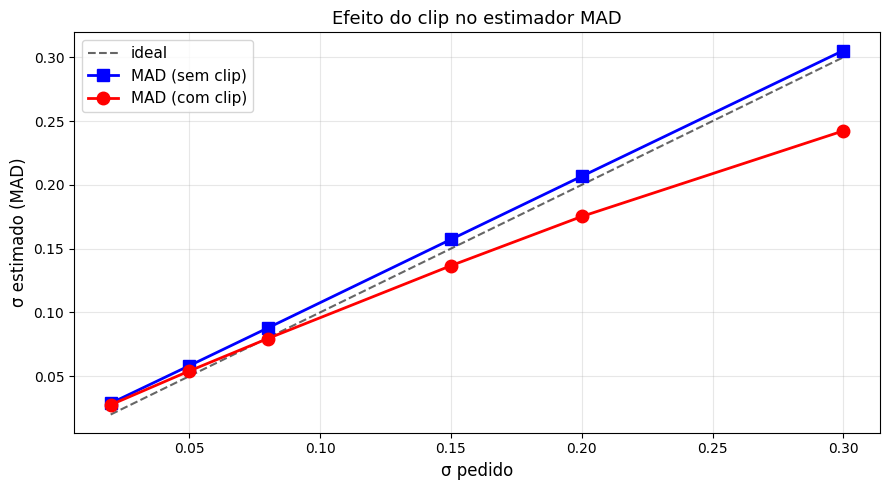

Sem clip, o MAD recupera o σ pedido quase perfeitamente.
Com clip, o desvio entre σ pedido e estimado cresce com o ruído
, mas o MAD está certo: ele mede o ruído que realmente existe na imagem.


In [20]:
# comparacao mad com e sem clip
niveis_ext = [0.02, 0.05, 0.08, 0.15, 0.20, 0.30]
resultados_clip = []

for s in niveis_ext:  # type: ignore[name-defined]
    rng_local = np.random.default_rng(42)
    ruido_local = rng_local.normal(0, s, f.shape)  # type: ignore[name-defined]

    g_sem_clip = f + ruido_local  # type: ignore[name-defined]
    g_com_clip = np.clip(g_sem_clip, 0, 1)

    resultados_clip.append({
        'σ pedido':         s,
        'MAD (sem clip)':   estimar_sigma_mad(g_sem_clip),  # type: ignore[name-defined]
        'MAD (com clip)':   estimar_sigma_mad(g_com_clip),  # type: ignore[name-defined]
    })

df_clip = pd.DataFrame(resultados_clip)
print(df_clip.round(4).to_string(index=False))  # type: ignore[name-defined]

# grafico
fig, ax = plt.subplots(figsize=(9, 5))
x_ext = np.array(niveis_ext)  # type: ignore[name-defined]

ax.plot(x_ext, x_ext, 'k--', linewidth=1.5, label='ideal', alpha=0.6)
ax.plot(x_ext, df_clip['MAD (sem clip)'], 'b-s', linewidth=2, markersize=9, label='MAD (sem clip)')  # type: ignore[name-defined]
ax.plot(x_ext, df_clip['MAD (com clip)'], 'r-o', linewidth=2, markersize=9, label='MAD (com clip)')  # type: ignore[name-defined]

ax.set_xlabel('σ pedido', fontsize=12)
ax.set_ylabel('σ estimado (MAD)', fontsize=12)
ax.set_title('Efeito do clip no estimador MAD', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Sem clip, o MAD recupera o σ pedido quase perfeitamente.')
print('Com clip, o desvio entre σ pedido e estimado cresce com o ruído')
print(', mas o MAD está certo: ele mede o ruído que realmente existe na imagem.')


## Parte E: Fechamento e perguntas finais

### Perguntas

**6. Qual estimador você recomendaria na prática? Justifique.**

> O estimador MAD é o mais recomendado na prática. Ele é robusto a bordas e texturas da imagem, ou seja, não superestima o ruído em regiões com muita variação de intensidade. Diferentemente do desvio-padrão global (que mede variabilidade da cena, não do ruído) e do estimador por diferenças (que é sensível a bordas), o MAD fornece estimativas precisas mesmo em imagens complexas.

**7. O que acontece com os estimadores quando o ruído é muito forte (ex: σ=0.20)?**

> Com ruído forte, o  corta parte das amostras de ruído que tentam empurrar pixels para fora de [0, 1]. Isso faz com que o ruído efetivamente presente na imagem tenha desvio menor que o σ que pedimos ao gerador. O MAD "acerta" esse σ efetivo — ele não está errando, está medindo corretamente o ruído que realmente sobrou após o clip.

**8. Como você modificaria o experimento para isolar a contribuição do clipping?**

> Basta rodar dois experimentos paralelos: um aplicando clip e outro sem clip, e comparar os resultados do MAD em ambos os casos. A diferença entre os dois mostra exatamente o quanto o clip reduz o ruído efetivo.

**9. Por que a estimativa global (np.std) fica quase constante independente do ruído?**

> Porque  mede a variabilidade total da imagem, que é dominada pela variabilidade natural da cena (σ_f ≈ 0,26). Como σ_total = √(σ_f² + σ_ruído²), e σ_f >> σ_ruído para ruídos moderados, o valor global quase não muda.
